<a href="https://colab.research.google.com/github/Swastika200105/My-daily-data-science-journal-/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# import required linraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

In [3]:
# load datasets
df = pd.read_csv('/content/WineQT.csv')
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [4]:
#Analyzing the data
df.shape

(1143, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [9]:
df.describe().T # T means transpose

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [10]:
df.columns.tolist()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality',
 'Id']

In [12]:
# checking missing values
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [16]:
#checking duplicate values
df.duplicated().sum()

np.int64(0)

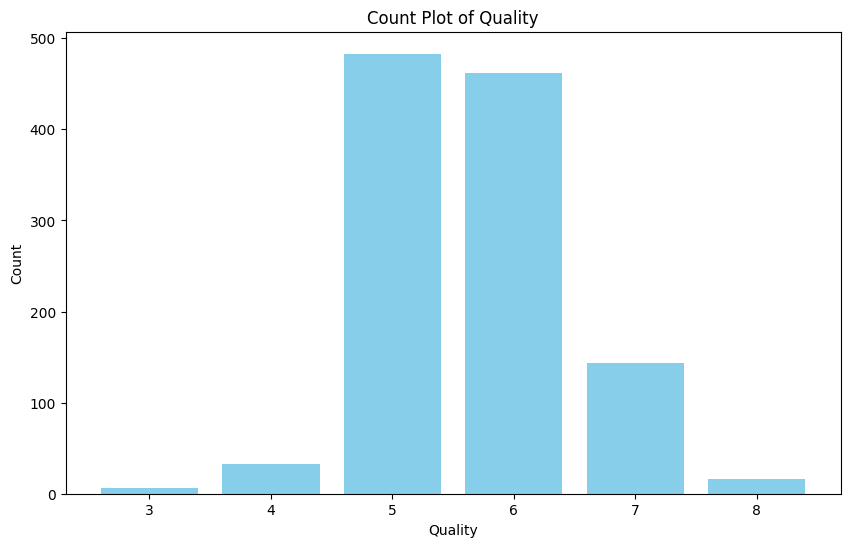

In [18]:
# Univariate Analysis
# Bar Plot
quality_counts = df['quality'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(quality_counts.index, quality_counts, color='skyblue')
plt.title('Count Plot of Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

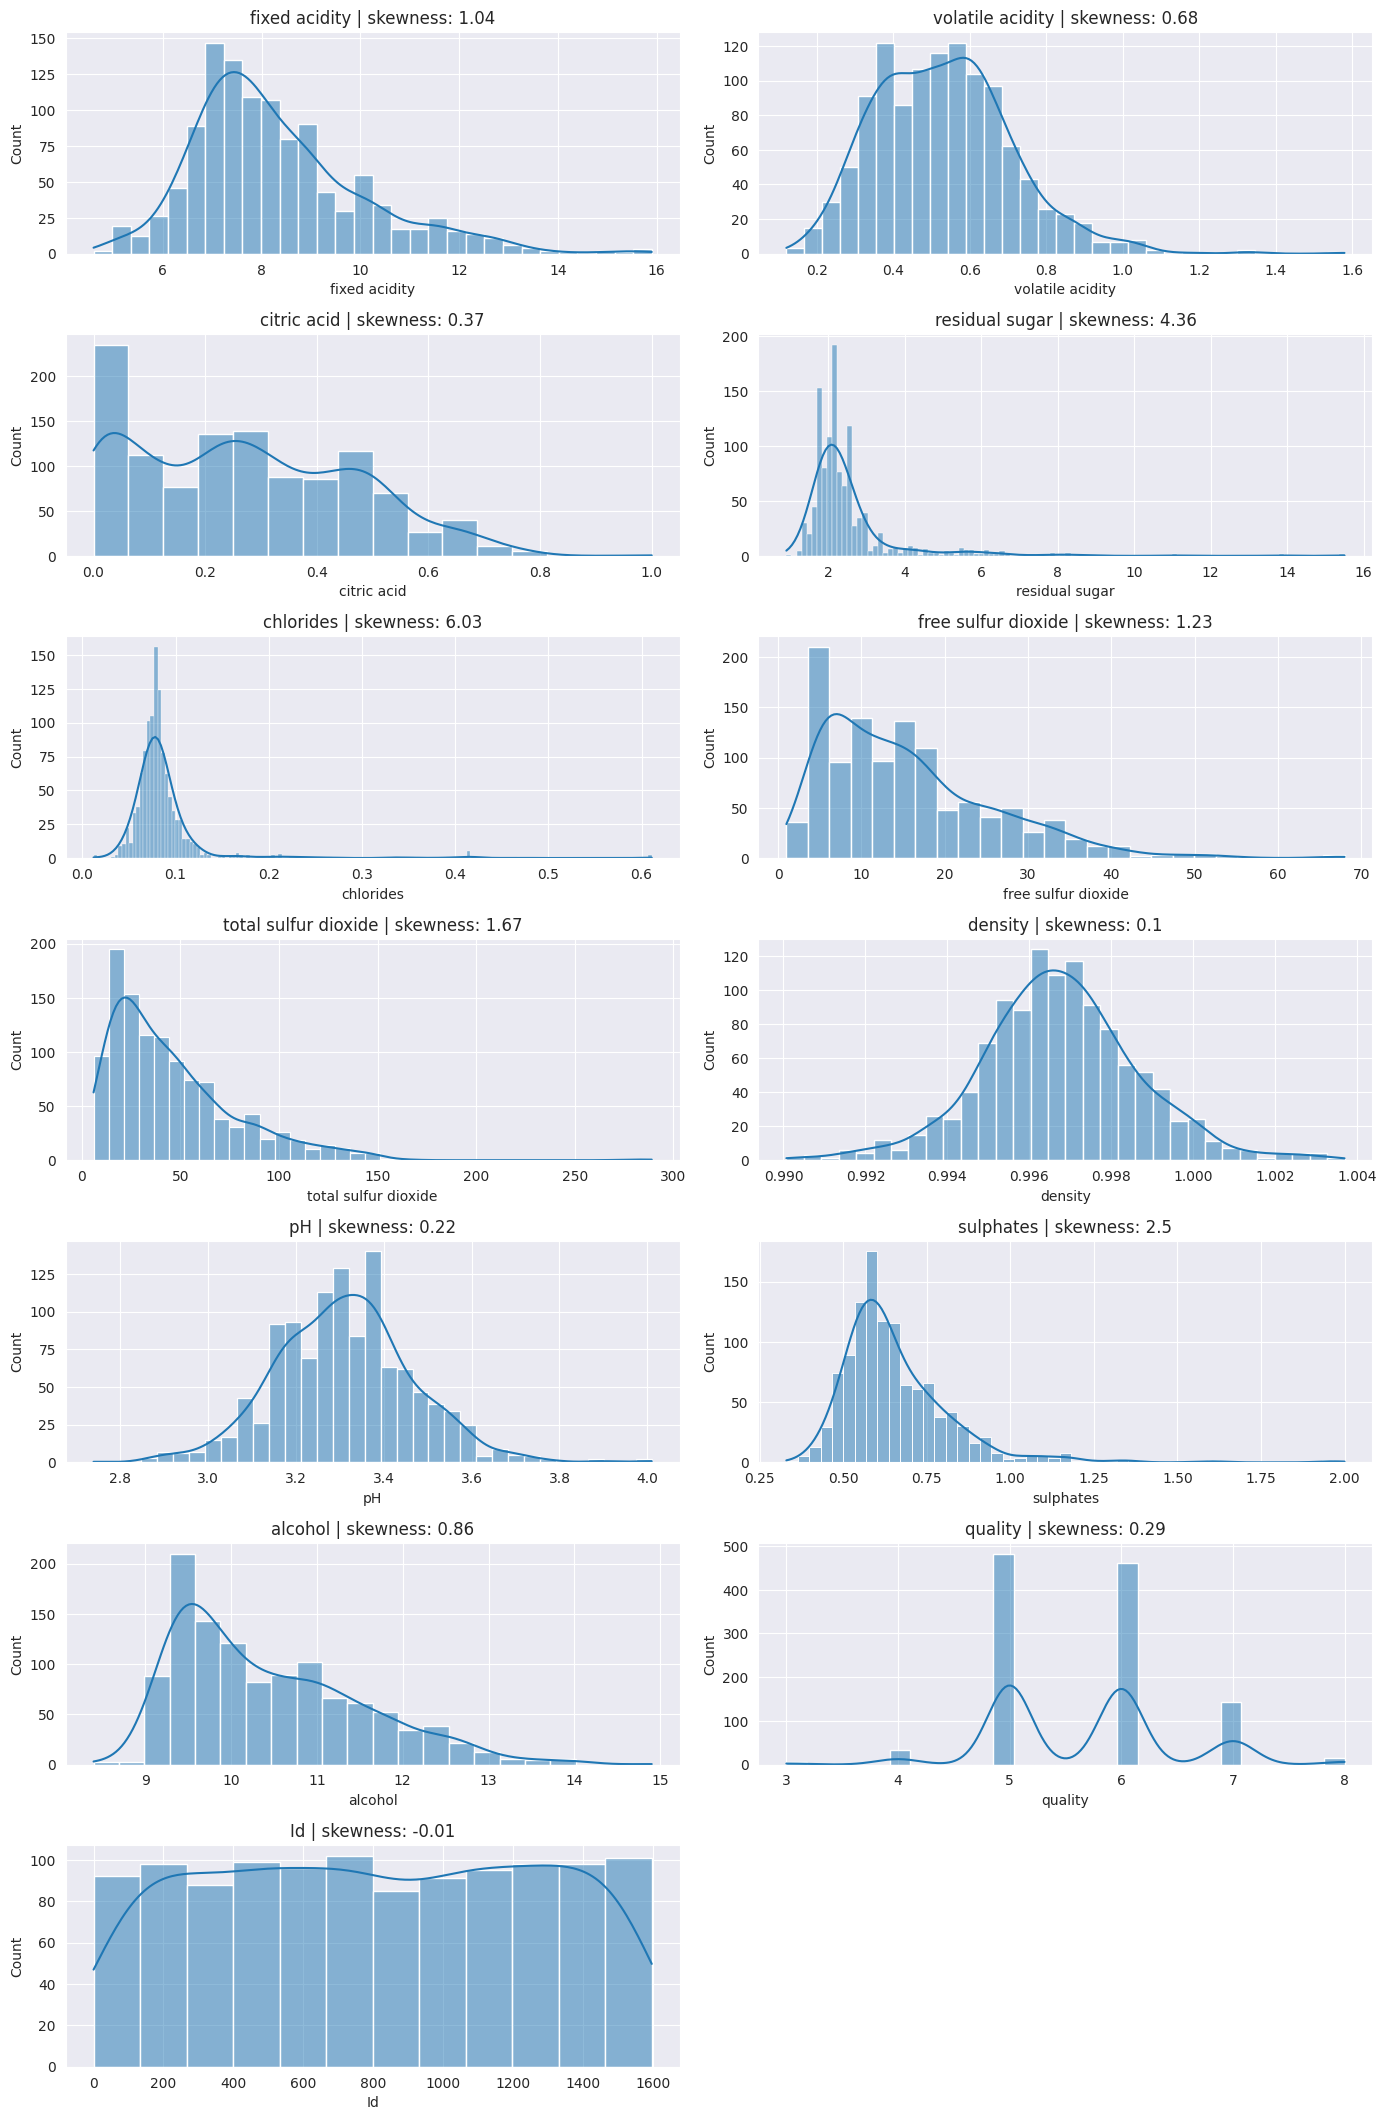

In [24]:
#Kernel density plots help visualize the distribution of data and identify patterns such as skewness and density.
sns.set_style('darkgrid')

numerical_columns = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
  plt.subplot(len(numerical_columns), 2, idx)
  sns.histplot(df[feature], kde=True)
  plt.title(f"{feature} | skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

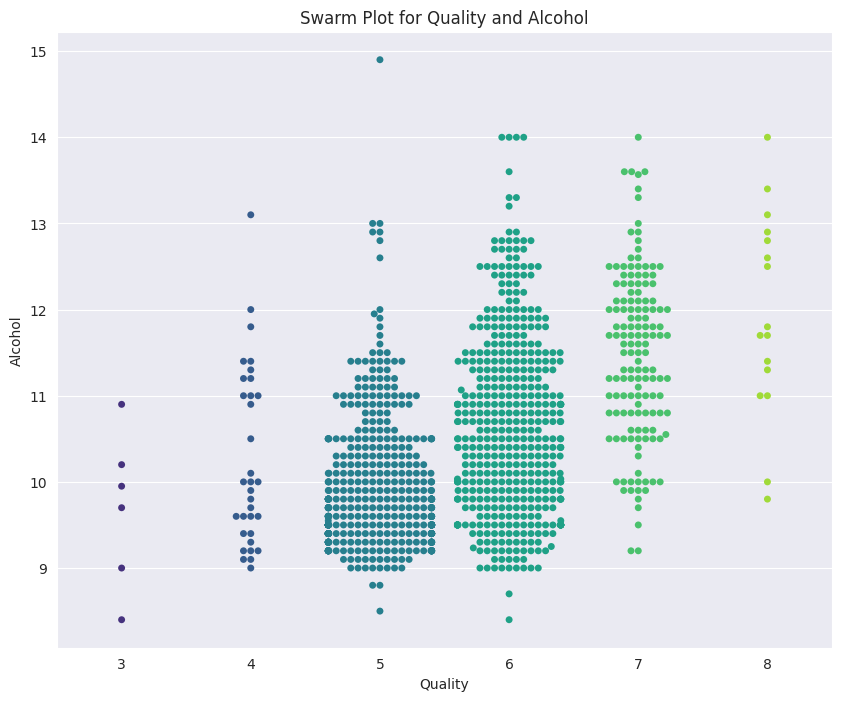

In [25]:
# Swarm Plot
plt.figure(figsize=(10,8))

sns.swarmplot(x="quality", y="alcohol", data=df, palette='viridis')

plt.title('Swarm Plot for Quality and Alcohol')
plt.xlabel('Quality') # This line sets the label for the x-axis
plt.ylabel('Alcohol')
plt.show()

<Figure size 500x600 with 0 Axes>

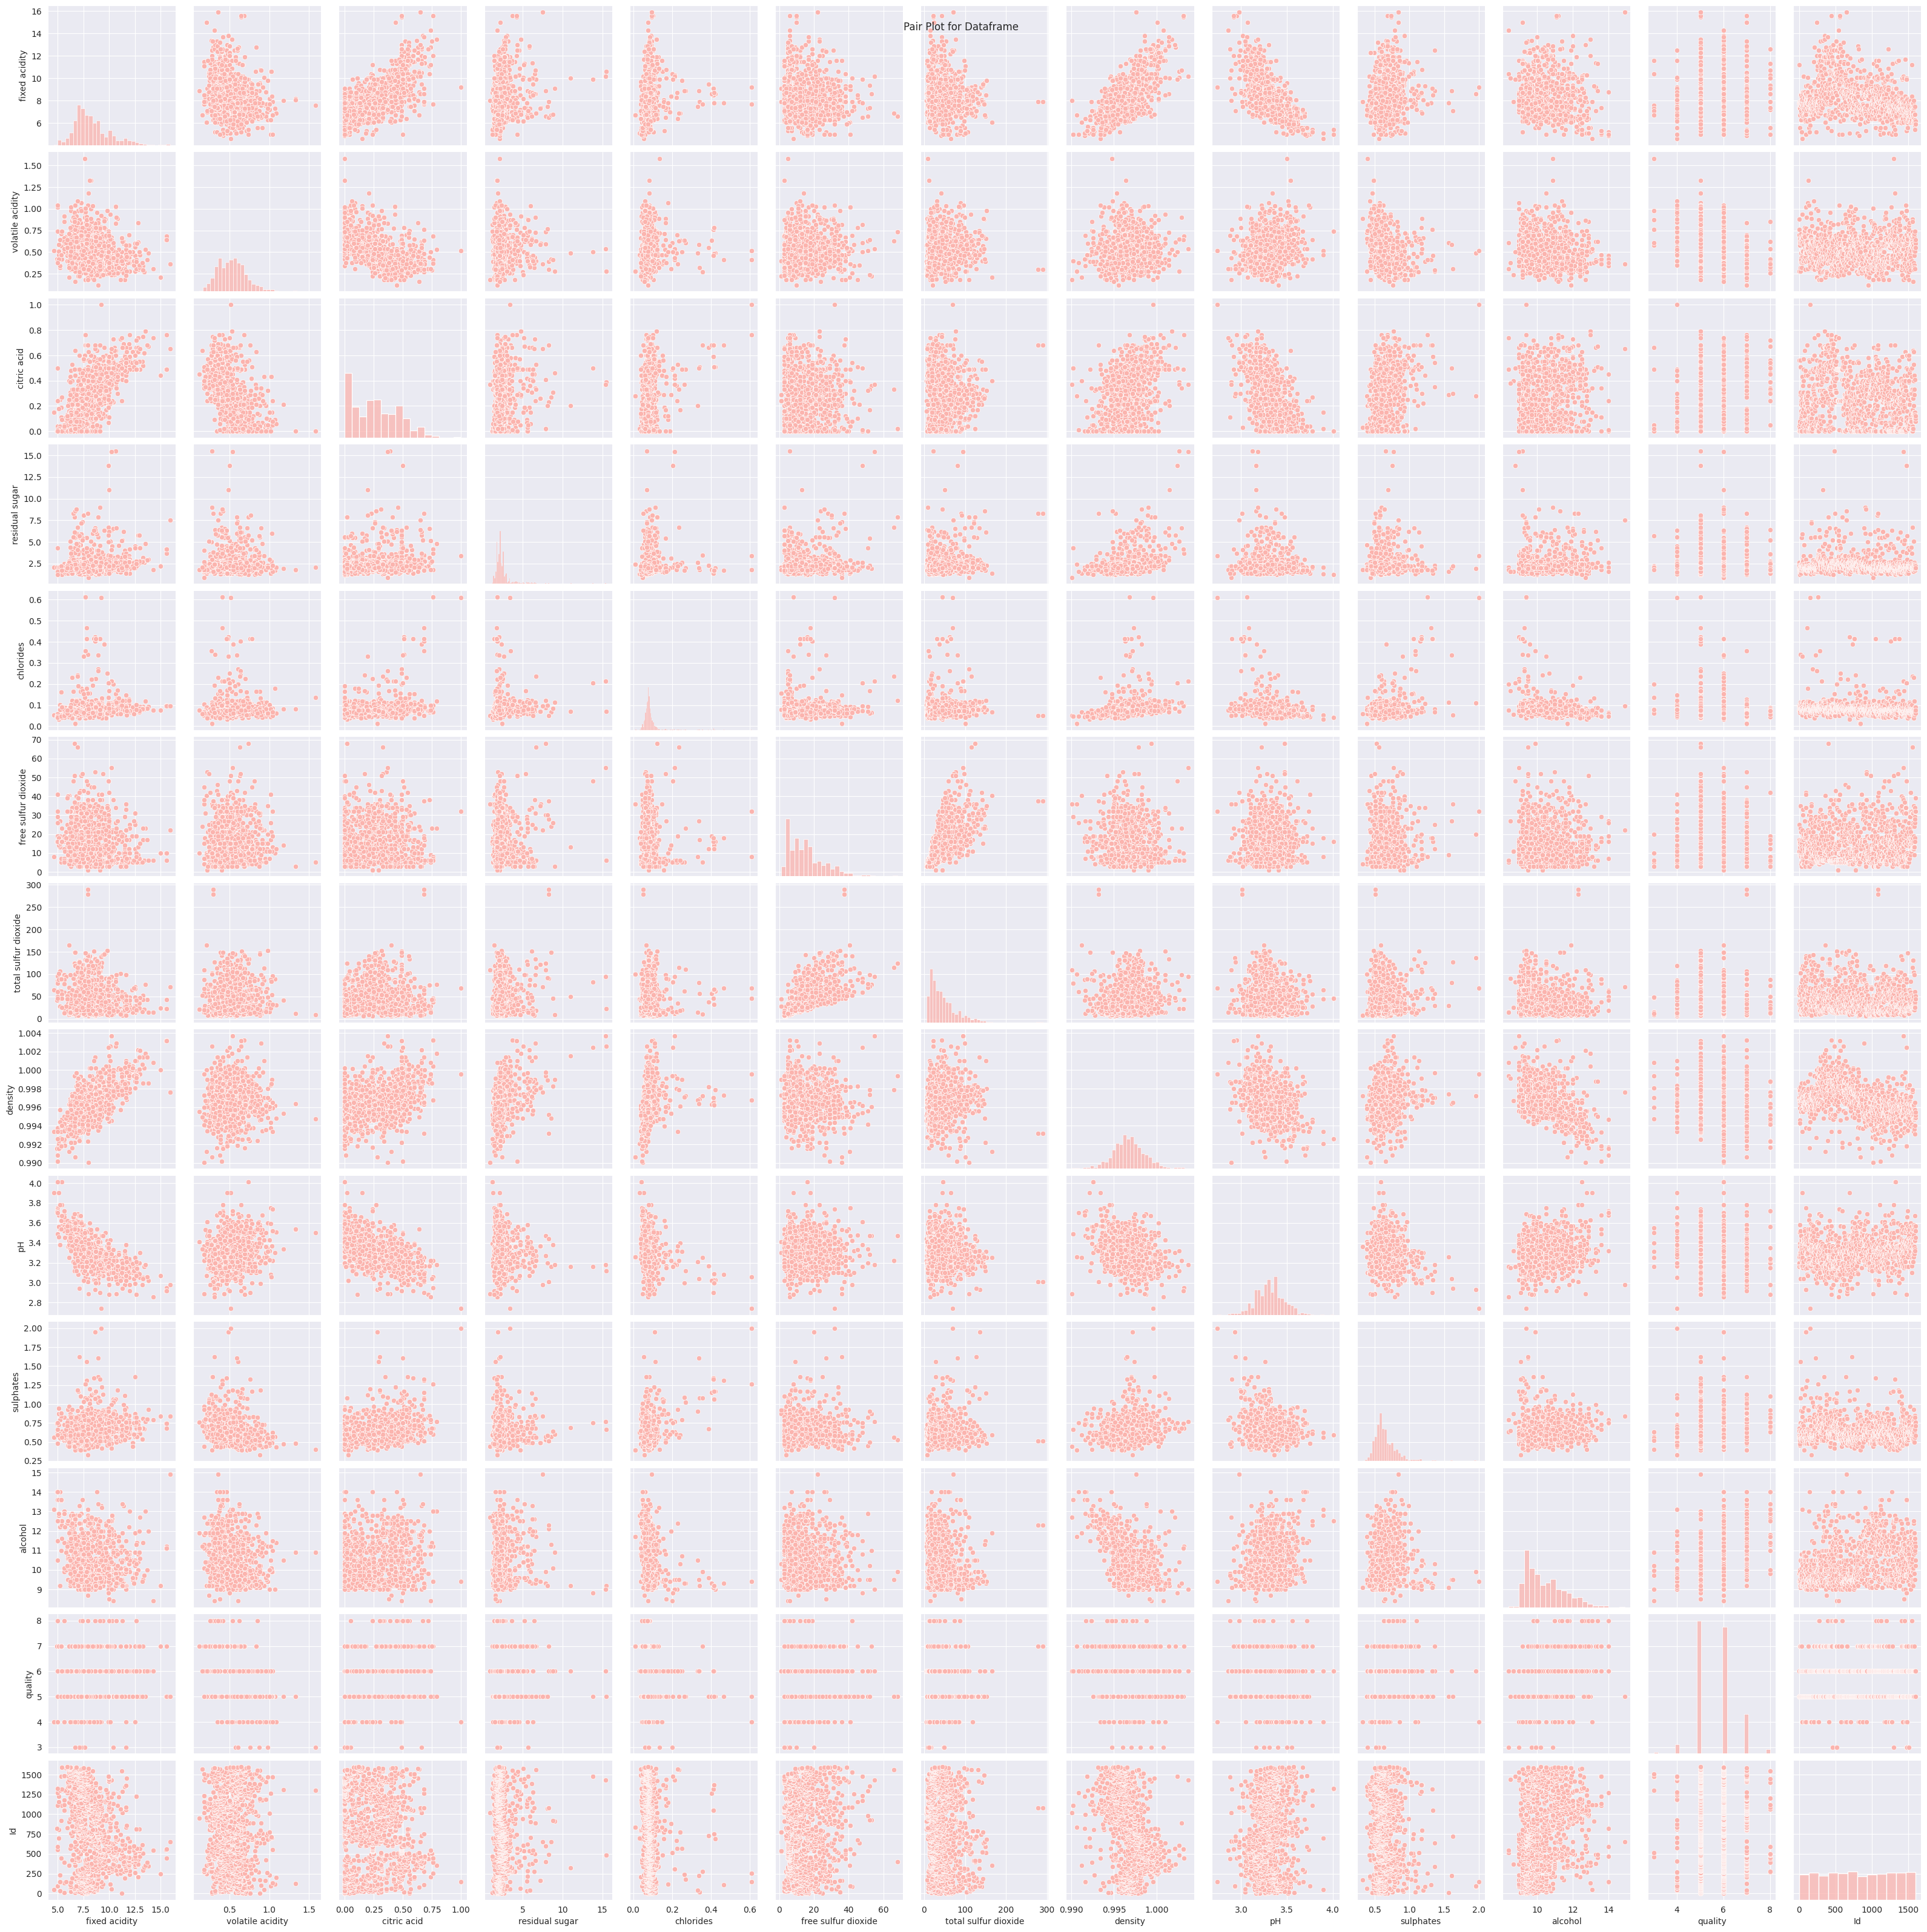

In [28]:
# Bivariate Analysis with Pair plot
sns.set_palette('Pastel1')

plt.figure(figsize=(5,6))

sns.pairplot(df)

plt.suptitle('Pair Plot for Dataframe')
plt.show()

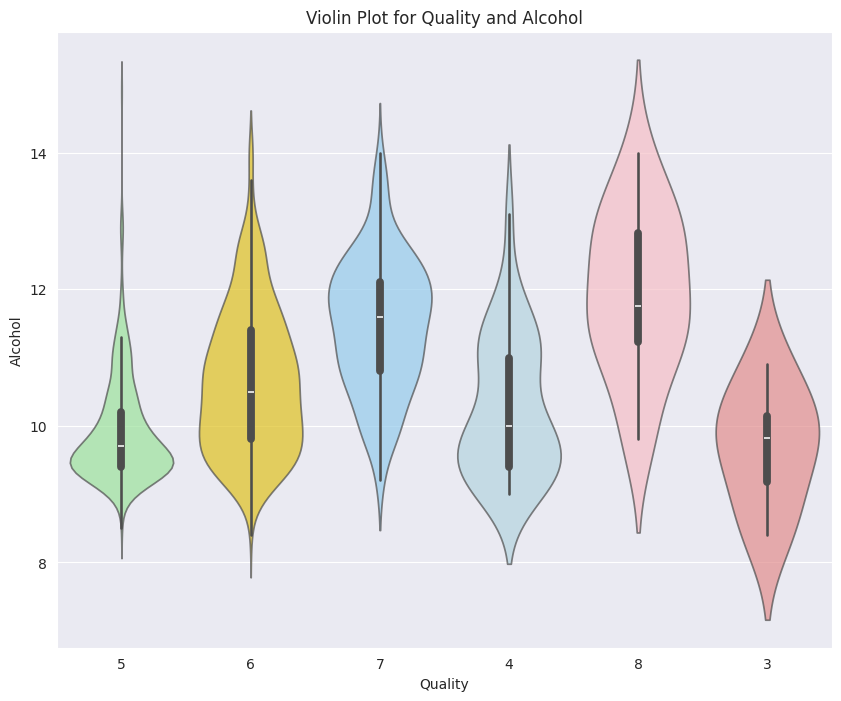

In [34]:
#Violin Plot
df['quality'] = df['quality'].astype(str)

plt.figure(figsize=(10, 8))

sns.violinplot(x="quality", y="alcohol", data=df, palette={
    '3': 'lightcoral', '4': 'lightblue', '5': 'lightgreen',
    '6': 'gold', '7': 'lightskyblue', '8': 'lightpink'}, alpha=0.7)

plt.title('Violin Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.show()

In [35]:
color_palette = {
    '3': 'lightcoral', '4': 'lightblue', '5': 'lightgreen',
    '6': 'gold', '7': 'lightskyblue', '8': 'lightpink'
}

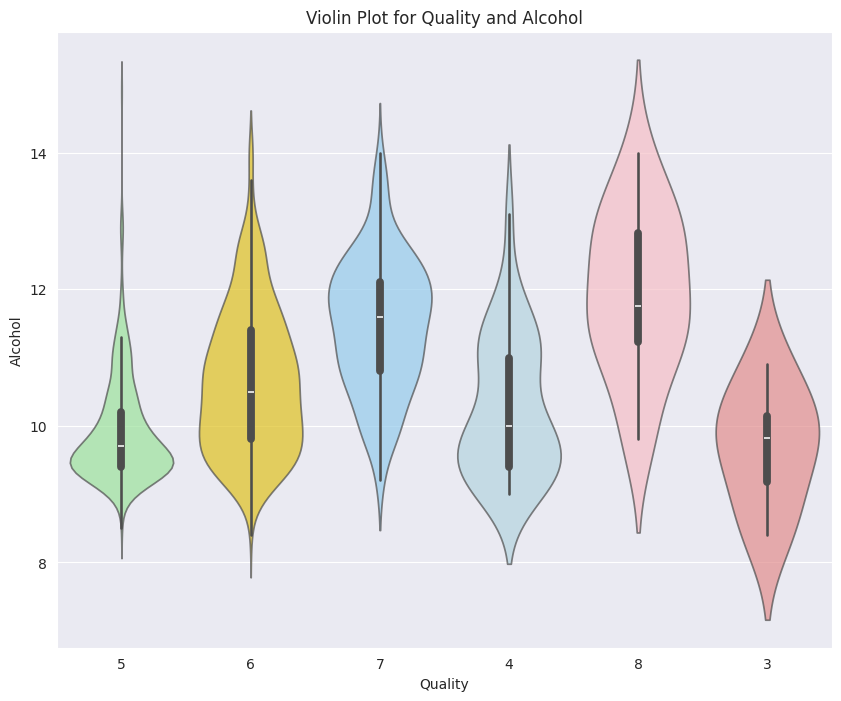

In [36]:
plt.figure(figsize=(10, 8))
sns.violinplot(x="quality", y="alcohol", data=df, palette=color_palette, alpha=0.7)
plt.title('Violin Plot for Quality and Alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.show()

<Axes: xlabel='quality', ylabel='alcohol'>

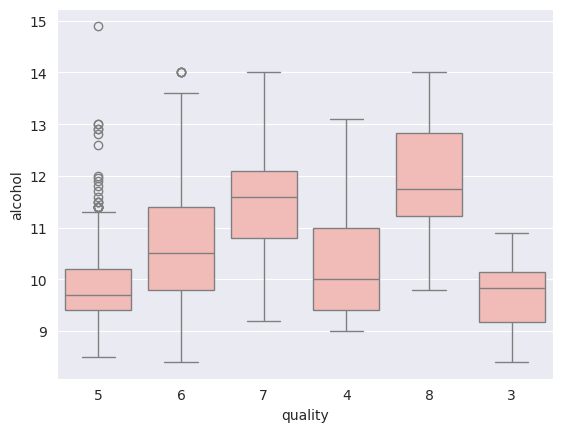

In [37]:
sns.boxplot(x='quality', y='alcohol', data=df)

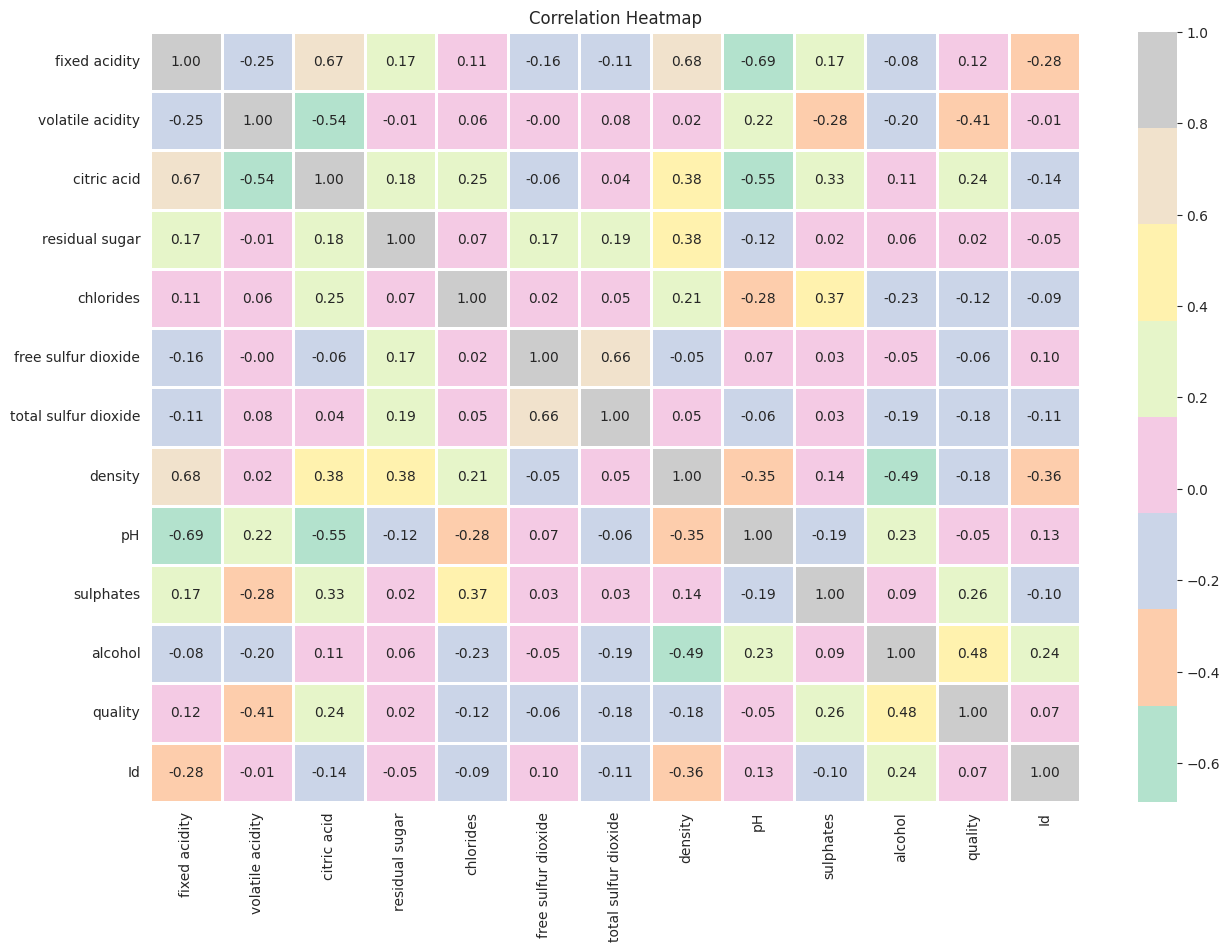

In [39]:
# Multivariate Analysis
plt.figure(figsize=(15, 10))

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()